<a href="https://colab.research.google.com/github/i-malur/bootcamp-dados-desafio-python-2/blob/main/%5BOFICIAL%5D_Challenge_Frequ%C3%AAncia_e_Medidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SQUAD DOROTHY VAUGHAN

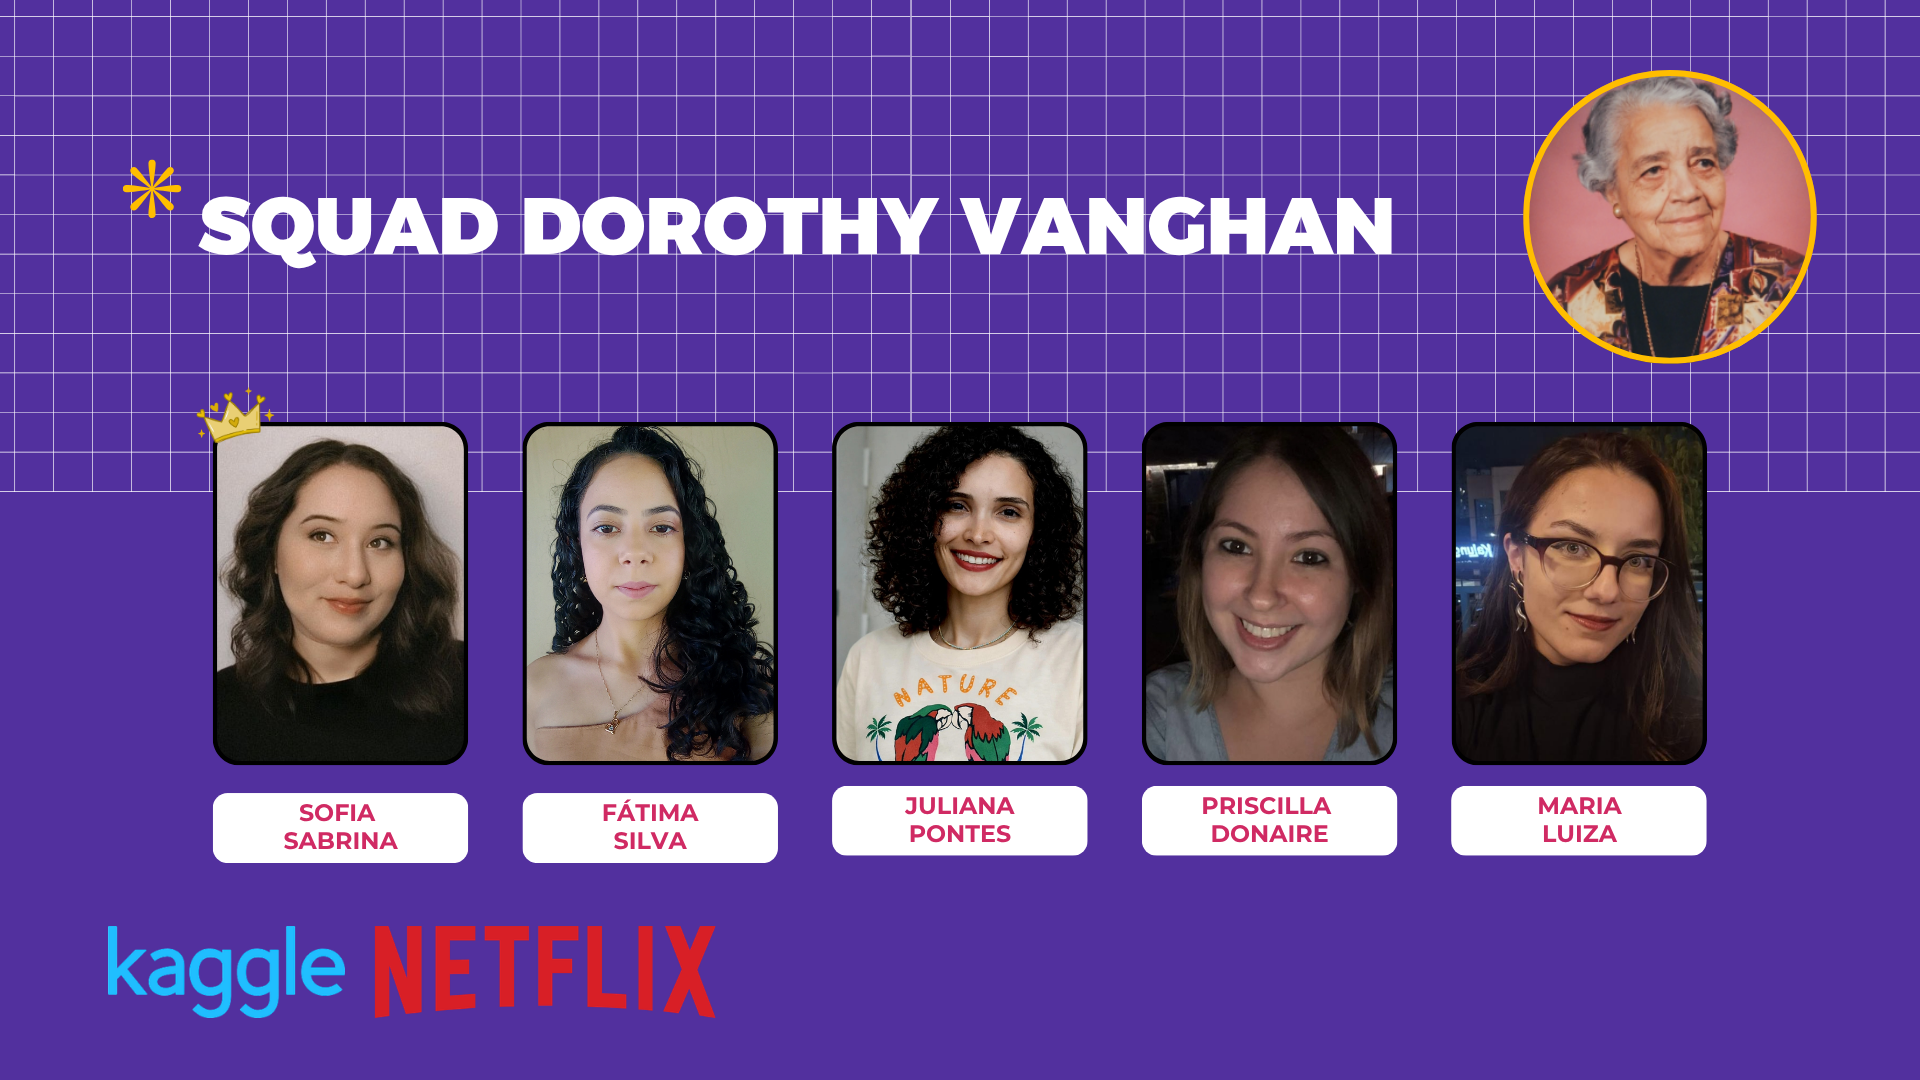

Arquivo .csv dos dados:

[netflix_titles_nov_2019.csv](https://drive.google.com/file/d/1cInLNo7aacuM80IA5iY84YGz40kmJc5d/view?usp=drive_link)

Pasta com os arquivos do desafio:

[Desafio - Challenge Frequência e Medidas](https://drive.google.com/drive/folders/1Mx-A-VAZ-Dv36H_f5z0ZcL02HfkhM6Xl?usp=sharing)


Variáveis:
* show_id - id único do filme/série.
* title - título do filme ou série
* director - diretor do filme ou série
* cast - elenco do filme ou série
* country - país do filme ou série
* date_added - data que foi adicionado no Netflix
* reading score - ano de lançamento original do filme
* rating - classificação da televisão
* duration - duração total do filme ou série.
* listed_in - categoria ou gênero do filme ou série.
* description -descrição do filme ou série.
* type - tipo de filme ou série


# Como a squad se organizou?

Nós criamos mais uma atividade extra para deixar a quantidade de perguntas iguais para todas as integrantes. Nos dividimos para responder as perguntas, onde cada integrante ficou com 2 perguntas e cada uma demonstrou as perguntas que desejava responder.

Antes de reunirmos nossas respostas, cada integrante fez seu próprio colab e respondeu todas as perguntas, nos reunimos para discutir a lógica e assim, contribuir com o trabalho em grupo.

Criamos um colab geral onde cada uma adicionou sua lógica nas suas perguntas e descreveu como foi realizada.


# Facilidades e dificuldades encontradas no desenvolvimento do desafio

Facilidades:

Dificuldades:


# 0. Preparação de ambiente

In [1]:
# bibliotecas de base
import pandas as pd
import numpy as np

# bibliotecas para visualização dos dados
import seaborn as sns
import matplotlib.pyplot as plt

# bibliotecas auxiliares
from collections import Counter

# biblioteca para estatística
import scipy.stats as stat

In [2]:
url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/challenge-frequencia-medidas/refs/heads/main/netflix_titles_nov_2019.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


# 1.  Exploração inicial:

* Quantas linhas e colunas tem o dataset?

In [4]:
print(f'O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas')

O dataset possui 5837 linhas e 12 colunas


* Quais são os tipos das variáveis e se há valores ausentes?

In [5]:
resumo = pd.DataFrame({
    'Tipos de Dados': df.dtypes,
    'Valores Ausentes': df.isna().sum()
})

display(resumo)

,Tipos de Dados,Valores Ausentes
show_id,int64,0
title,object,0
director,object,1901
cast,object,556
country,object,427
date_added,object,642
release_year,int64,0
rating,object,10
duration,object,0
listed_in,object,0


# 2. Análises de frequência:

* Qual a proporção de filmes vs. séries no catálogo?

In [6]:
# vendo quantos titulos sao filme e quantos sao serie
contagem_tipo = df['type'].value_counts()
print(contagem_tipo)

total = len(df)
for tipo, qtd in contagem_tipo.items():
    porcentagem = qtd / total * 100
    print(f'{tipo}: {qtd} titulos ({porcentagem:.1f}%)')

type
Movie      3939
TV Show    1898
Name: count, dtype: int64
Movie: 3939 titulos (67.5%)
TV Show: 1898 titulos (32.5%)


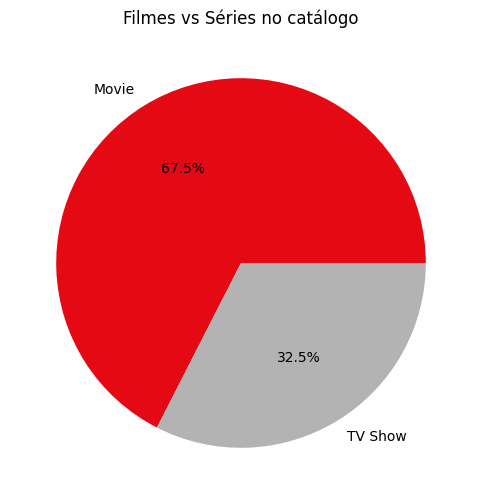

In [7]:
# grafico de pizza para melhor visualização
contagem_tipo.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), colors=['#E50914','#B3B3B3'])
plt.title('Filmes vs Séries no catálogo')
plt.ylabel('')
plt.show()

* Qual o gênero mais frequente?

In [8]:
# quebrando a coluna listed_in para contar genero por genero
lista_generos = []

for linha in df['listed_in'].dropna():
    generos_da_linha = linha.split(',')
    for g in generos_da_linha:
        lista_generos.append(g.strip())

contagem_generos = Counter(lista_generos)

# top 10 generos mais comuns
top10 = contagem_generos.most_common(10)

for genero, qtd in top10:
    print(genero, '-', qtd)

International Movies - 1797
Dramas - 1488
Comedies - 992
International TV Shows - 966
Documentaries - 658
TV Dramas - 574
Action & Adventure - 532
Independent Movies - 516
TV Comedies - 425
Crime TV Shows - 355


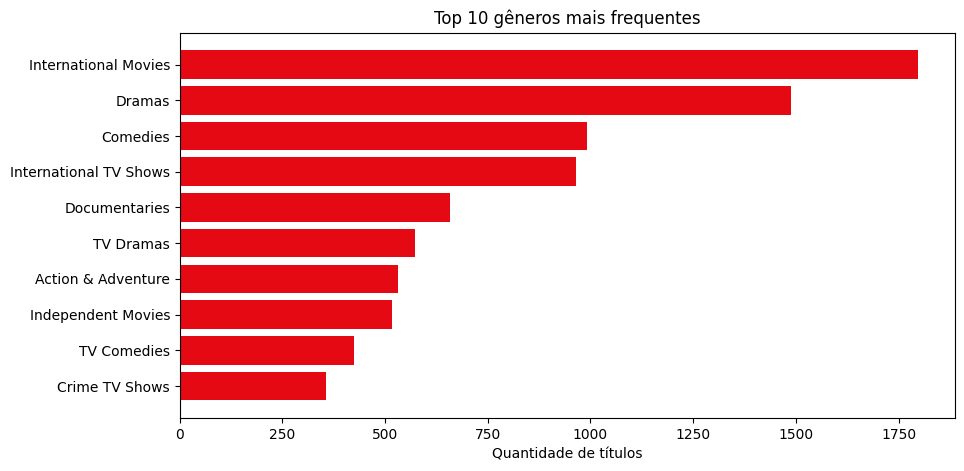

In [9]:
# grafico de barras com os 10 generos mais frequentes
nomes = [g[0] for g in top10]
qtds = [g[1] for g in top10]

plt.figure(figsize=(10,5))
plt.barh(nomes, qtds, color='#E50914')
plt.gca().invert_yaxis()
plt.xlabel('Quantidade de títulos')
plt.title('Top 10 gêneros mais frequentes')
plt.show()

# 3.  Análises estatísticas:

* Qual a média, mediana e moda do tempo de duração dos
filmes?


In [10]:
# Filtra apenas as linhas que são filmes
df_filmes = df[df['type'] == 'Movie'].copy()

# Limpa a coluna de duração removendo o texto ' min' e converte para inteiro
df_filmes['duracao_filmes'] = df_filmes['duration'].str.replace(' min', '', regex=False).astype(int)

# Calcular as medidadas
duracao_media   = df_filmes['duracao_filmes'].mean()
duracao_moda    = df_filmes['duracao_filmes'].mode()[0]
duracao_mediana = df_filmes['duracao_filmes'].median()

# Exibe os resultados
print("ESTATÍSTICAS DE DURAÇÃO DOS FILMES")
print(f"A duração média dos filmes é: {duracao_media:.2f} minutos")
print(f"A moda da duração dos filmes é: {duracao_moda} minutos")
print(f"A mediana da duração dos filmes é: {duracao_mediana} minutos")

ESTATÍSTICAS DE DURAÇÃO DOS FILMES
A duração média dos filmes é: 98.03 minutos
A moda da duração dos filmes é: 90 minutos
A mediana da duração dos filmes é: 97.0 minutos


* Qual o filme mais curto e mais longo?

In [11]:
# 1. Encontra o ID da linha do filme mais curto e do mais longo
indice_menor_filme = df_filmes['duracao_filmes'].idxmin()
indice_maior_filme = df_filmes['duracao_filmes'].idxmax()

# 2. Busca a linha desses filmes
filme_curto = df_filmes.loc[indice_menor_filme]
filme_longo = df_filmes.loc[indice_maior_filme]

# 3. Exibe as informações
print("FILME MAIS CURTO")
print(f"Título: {filme_curto['title']}")
print(f"Duração: {filme_curto['duracao_filmes']} minutos")

print("\nFILME MAIS LONGO")
print(f"Título: {filme_longo['title']}")
print(f"Duração: {filme_longo['duracao_filmes']} minutos")

FILME MAIS CURTO
Título: Silent
Duração: 3 minutos

FILME MAIS LONGO
Título: Black Mirror: Bandersnatch
Duração: 312 minutos


# 4. Visualização de dados:


* Criar um gráfico de barras para mostrar a quantidade de títulos
por gênero.


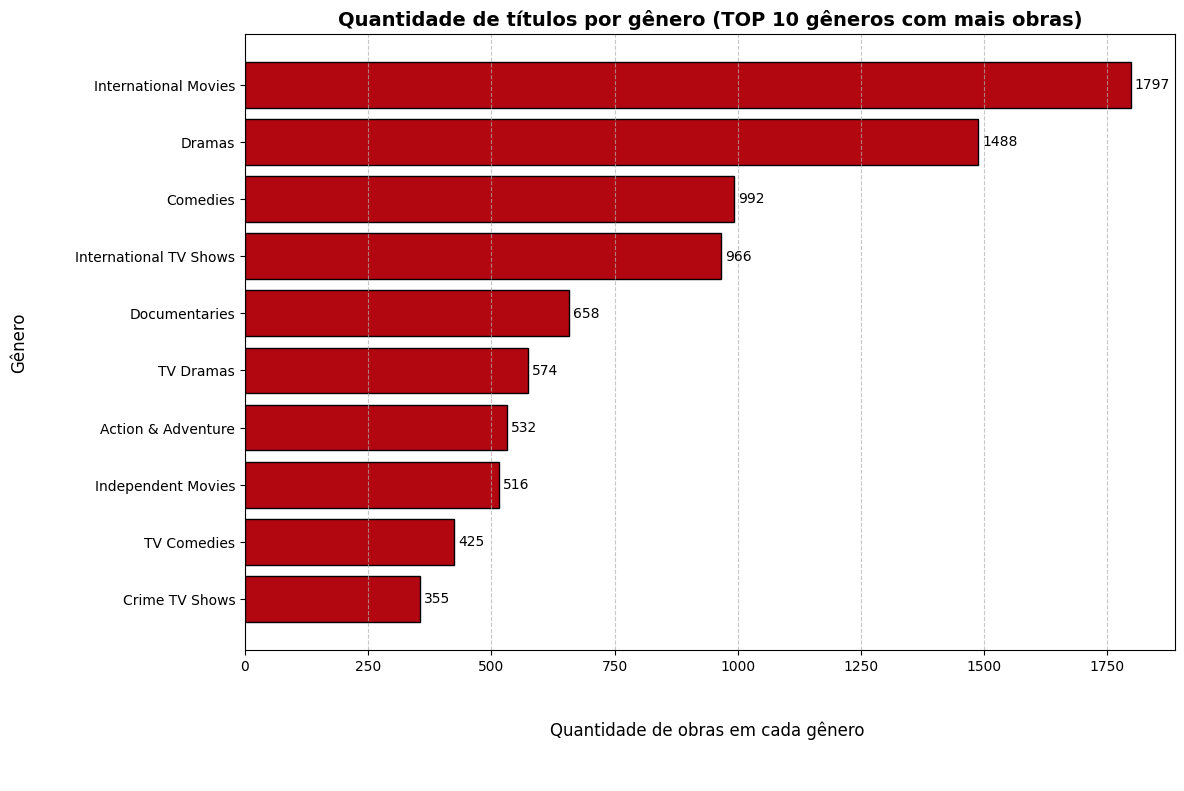

'\nexplode() pega uma linha que tem vários generos e a "duplica", criando uma linha para cada genero.\n\nComo funciona na prática?\nPodemos ter:\nMatrix | [\'Ação\', \'Ficção Científica\']\n\nO .explode() transforma em duas linhas:\nMatrix | Ação\nMatrix | Ficção Científica\n'

In [34]:
df_obras_genero = df.copy()

# armazenando em uma variável toda a coluna de gênero.
# Cada linha terá uma lista de gênero de filmes, ex: [Drama, Ficção Científica, Romance]
obras_genero_unico = df_obras_genero['listed_in'].str.split(',')

# usando método explode para separar os itens da lista e deixar cada gênero em uma linha
obras_genero_explode = obras_genero_unico.explode()

# removendo espaços antes e depois de cada gênero
obras_genero_explode = obras_genero_explode.str.strip()

# contando as ocorrências de cada gênero
df_obras_genero = obras_genero_explode.value_counts().reset_index() # criando dataframe

# renomeando colunas do dataframe
df_obras_genero.columns = ['genero', 'ocorrencias']

# aqui, salvo em uma variável os 10 primeiros generos do dataframe
contagem_generos_explode = df_obras_genero.head(10)

# criando variável com a sequência do maior para o menor
ordem_barras = contagem_generos_explode.iloc[::-1]

# criando gráfico
plt.figure(figsize=(12,8))  # comprimento e largura do gráfico
grafico = plt.barh(ordem_barras['genero'], ordem_barras['ocorrencias'], color='#B20710', edgecolor='black') # criando gráfico
plt.bar_label(grafico, padding=3) # adicionando rótulos em cima das barras

# personalizando o gráfico
plt.title('Quantidade de títulos por gênero (TOP 10 gêneros com mais obras)', fontsize=14, fontweight='bold') # título do gráfico
plt.xlabel('\n\nQuantidade de obras em cada gênero \n\n', fontsize=12) # título do eixo x
plt.ylabel('Gênero\n\n', fontsize=12) # título do eixo y
plt.grid(axis='x', linestyle='--', alpha=0.7)  # adiciona linhas de grade verticais

plt.show()

'''
explode() pega uma linha que tem vários generos e a "duplica", criando uma linha para cada genero.

Como funciona na prática?
Podemos ter:
Matrix | ['Ação', 'Ficção Científica']

O .explode() transforma em duas linhas:
Matrix | Ação
Matrix | Ficção Científica
'''

* Criar um histograma para analisar a distribuição da duração dos
filmes.

In [13]:
# criando códia do df e filtrando que são vão ter os registros de filmes
df_filmes = df[df['type'] == 'Movie'].copy()

# criando nova coluna onde adicionamos a duração, retiramos o texto 'min' e transformamos em inteiro
df_filmes['duration_num'] = df_filmes['duration'].str.replace(' min', '').astype(int)
df_filmes.head(2)

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type,duration_num
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,67
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,135


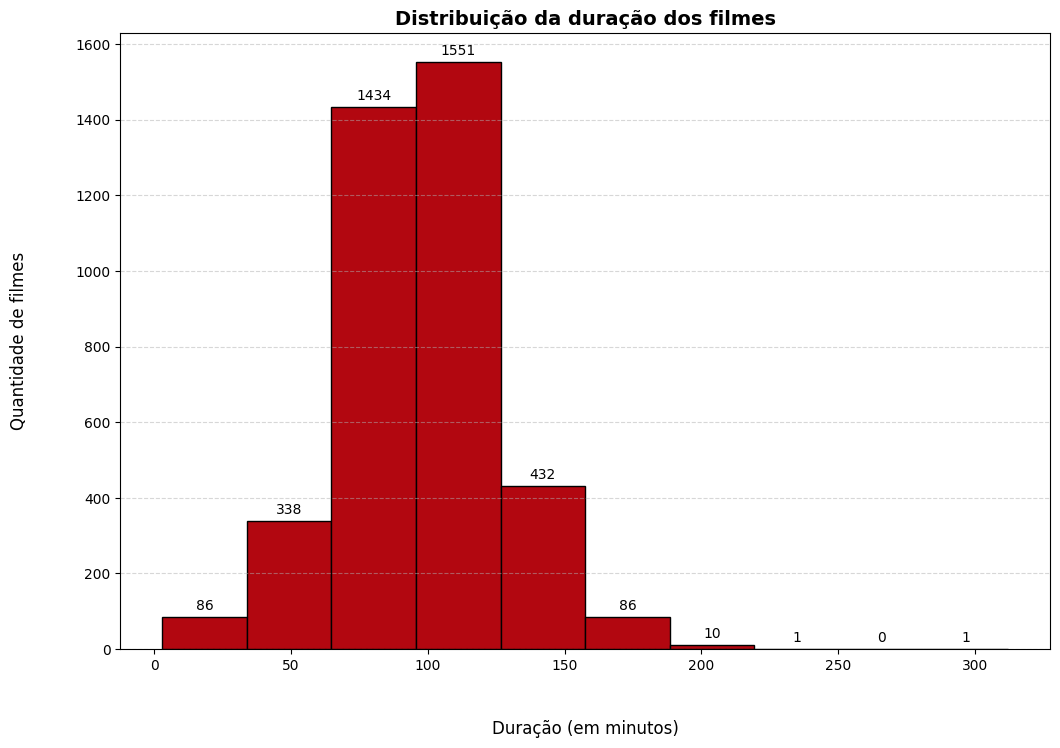

'\nO plt.hist() retorna uma tupla com 3 itens:\n\nOs valores de cada barra (contagens): Um array com o número de elementos que caíram dentro de cada intervalo (bin).\nAs divisões dos intervalos (bins): Um array com as coordenadas de onde cada barra começa e termina no eixo X.\nOs objetos visuais das barras (patches): Uma lista de objetos geométricos (retângulos) que o Matplotlib desenha na tela. Ou seja, as barras.\n'

In [14]:
# dimensões do histograma
plt.figure(figsize=(12,8))

# O parâmetro 'bins' define em quantas "barras/faixas" os dados serão divididos
# para conseguirmos colocar os rótulos em cada barra, usamos _, _, para a variável armazenar o terceiro retorno do plt.hist (ou seja, as barras)
_, _, histograma = plt.hist(df_filmes['duration_num'], bins=10, color='#B20710', edgecolor='black')

plt.title('Distribuição da duração dos filmes', fontsize=14, fontweight='bold') # título do gráfico
plt.xlabel('\n\nDuração (em minutos)', fontsize=12) # título eixo x
plt.ylabel('Quantidade de filmes\n\n', fontsize=12) # títiulo eixo y
plt.grid(axis='y', linestyle='--', alpha=0.5) # linhas de grade

plt.bar_label(histograma, padding=3) # adicionando rótulos em cima das barras

plt.show() # mostra o histograma


'''
O plt.hist() retorna uma tupla com 3 itens:

Os valores de cada barra (contagens): Um array com o número de elementos que caíram dentro de cada intervalo (bin).
As divisões dos intervalos (bins): Um array com as coordenadas de onde cada barra começa e termina no eixo X.
Os objetos visuais das barras (patches): Uma lista de objetos geométricos (retângulos) que o Matplotlib desenha na tela. Ou seja, as barras.
'''


# Atividade extra:

* Quais são os 5 países que possuem mais produções no catálogo?

In [15]:
df ['country']

,country
0,South Korea
1,NaN
2,India
3,"France, Senegal, Belgium"
4,"Canada, United Kingdom"
...,...
5832,United States
5833,United States
5834,Denmark
5835,United States


In [16]:
#verificando quantidade de países com valores nulos
df["country"].isnull().sum()

np.int64(427)

In [17]:
# Seleciona a coluna "country" do DataFrame
paises = (
    df["country"]

    # Remove os valores ausentes da coluna
    .dropna()

    # Separa os países que aparecem juntos usando a vírgula
    .str.split(",")

    # Coloca cada país em uma linha separada
    .explode()

    # Remove espaços extras antes e depois dos nomes
    .str.strip()
)

# Conta quantas vezes cada país aparece
# e seleciona os 5 países mais frequentes
top_5_paises = paises.value_counts().head(5)


print(top_5_paises)

country
United States     2421
India              753
United Kingdom     559
Canada             300
France             255
Name: count, dtype: int64




*   [PROPOSTA] Quantos títulos foram lançados por ano (olhe o ano original de lançamento do filme)? Faça o gráfico com o TOP 5 anos com mais lançamentos.


In [18]:
df['release_year']

,release_year
0,2019
1,2019
2,2019
3,2019
4,2019
...,...
5832,1987
5833,2009
5834,2007
5835,2007


In [19]:
# Conta quantos títulos foram lançados em cada ano
# e seleciona os 5 anos com maior quantidade
top_5_anos = df["release_year"].value_counts().head(5)

# Mostra os resultados antes de criar o gráfico
print(top_5_anos)


release_year
2018    1040
2017     928
2016     818
2019     762
2015     502
Name: count, dtype: int64


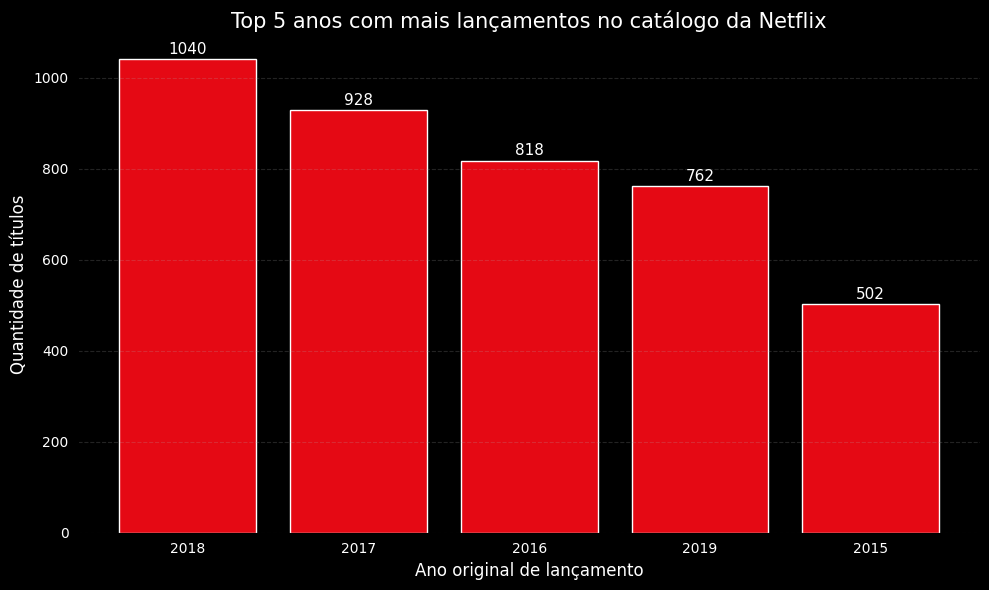

In [20]:
# Cria a figura e define o fundo preto
plt.figure(figsize=(10, 6), facecolor="black")

# Seleciona a área interna do gráfico
ax = plt.gca()

# Coloca o fundo interno preto
ax.set_facecolor("black")

# Cria o gráfico de barras
barras = plt.bar(
    top_5_anos.index.astype(str),  # anos no eixo horizontal
    top_5_anos.values,             # quantidade de títulos
    color="#E50914",               # vermelho Netflix
    edgecolor="white"              # borda branca
)

# Adiciona o título
plt.title(
    "Top 5 anos com mais lançamentos no catálogo da Netflix",
    fontsize=15,
    color="white"
)

# Adiciona o nome dos eixos
plt.xlabel("Ano original de lançamento", fontsize=12, color="white")
plt.ylabel("Quantidade de títulos", fontsize=12, color="white")

# Deixa os números dos eixos brancos
plt.xticks(color="white")
plt.yticks(color="white")

# Adiciona uma grade leve no eixo vertical
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

# Coloca a quantidade acima de cada barra
for barra in barras:
    quantidade = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade + 5,
        str(int(quantidade)),
        ha="center",
        va="bottom",
        color="white",
        fontsize=11
    )

# Organiza os elementos do gráfico
plt.tight_layout()

# Mostra o gráfico
plt.show()